# Clean up indiviudal messages

Coco Yu  
August 19, 2024

## Code Status

## Setup

Chunk Defaults

In [ ]:
knitr::opts_chunk$set(attr.output='style="max-height: 500px;"')


Conflicts

In [ ]:
options(conflicts.policy = "depends.ok")


In [ ]:
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

here() starts at C:/Users/jyu274/Desktop/github/study_messages

Source Functions

In [ ]:
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")


ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "c045eee2655a18dc85e715b78182f176327358a7"

ℹ SHA-1 hash of file is "def6ce26ed7b2493931fde811adff9287ee8d874"

Absolute Paths

In [ ]:
path_shared <- format_path(str_c("studydata/risk/data_processed/shared"))
path_messages <- format_path(str_c("studydata/risk/data_processed/messages"))


## Read in Data

In [ ]:
data <- read_csv(here(path_shared, "sms.csv"), 
                 col_types = cols(
                   subid = "d", start_study = "T", end_study = "T",
                   address = "c", date = "T", type = "f", body = "c",
                   msg_type = "f", phone_type = "f"
                 )) |> 
  mutate(date = as_datetime(date, tz = "America/Chicago"),
         start_study = as_datetime(start_study, tz = "America/Chicago"),
         end_study = as_datetime(end_study, tz = "America/Chicago")) |> 
  glimpse()


Rows: 431,669
Columns: 9
$ subid       <dbl> 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2…
$ start_study <dttm> 2017-03-02, 2017-03-02, 2017-03-24, 2017-03-24, 2017-03-2…
$ end_study   <dttm> 2017-05-31, 2017-05-31, 2017-06-16, 2017-06-16, 2017-06-1…
$ address     <chr> "16085720721", "16085722496", "16082099771", "16082099771"…
$ date        <dttm> 2017-05-01 09:35:14, 2017-04-21 17:01:40, 2017-03-24 06:2…
$ type        <fct> received, received, sent, received, sent, received, receiv…
$ body        <chr> "Test", "Test Message Please type YES if you receive this …
$ msg_type    <fct> imessage, imessage, sms, sms, sms, sms, sms, sms, sms, sms…
$ phone_type  <fct> ios, ios, android, android, android, android, android, and…

## Data Cleaning

### Add Contact Information

read in contact data

In [ ]:
contacts <- read_csv(here(path_shared, "contacts.csv"),
                     col_types = cols(.default = col_character(),
                                      subid = "d"))


check format of address in contacts.csv

In [ ]:
nchar(contacts$phone_number) |> 
  tabyl()


 nchar(contacts$phone_number)    n      percent valid_percent
                            5   13 0.0017560448  0.0017562821
                            6    7 0.0009455626  0.0009456904
                            7    1 0.0001350804  0.0001350986
                           10 7364 0.9947318655  0.9948662524
                           12   17 0.0022963663  0.0022966766
                           NA    1 0.0001350804            NA

make address format consistent across contacts and data

In [ ]:
contacts <- contacts |> 
  mutate(
    phone_number = if_else(
      nchar(phone_number) == 10,
      paste0("1", phone_number),
      phone_number
    )
  )


combine data and contacts

In [ ]:
data <- contacts |> 
  group_by(subid) |> 
  summarize(freq_contacts = list(phone_number)) |>
  right_join(data, by = "subid") |> 
  glimpse()


Rows: 431,669
Columns: 10
$ subid         <dbl> 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,…
$ freq_contacts <list> <"16083588174", "16082227282", "16085149557", "16084385…
$ start_study   <dttm> 2017-03-02, 2017-03-02, 2017-03-24, 2017-03-24, 2017-03…
$ end_study     <dttm> 2017-05-31, 2017-05-31, 2017-06-16, 2017-06-16, 2017-06…
$ address       <chr> "16085720721", "16085722496", "16082099771", "1608209977…
$ date          <dttm> 2017-05-01 09:35:14, 2017-04-21 17:01:40, 2017-03-24 06…
$ type          <fct> received, received, sent, received, sent, received, rece…
$ body          <chr> "Test", "Test Message Please type YES if you receive thi…
$ msg_type      <fct> imessage, imessage, sms, sms, sms, sms, sms, sms, sms, s…
$ phone_type    <fct> ios, ios, android, android, android, android, android, a…

create new column freq_contacts: y/n

In [ ]:
data <- data |> 
  mutate(
    freq_contacts = if_else(
      address %in% unlist(freq_contacts),
      "yes", "no"
    ),
    freq_contacts = factor(freq_contacts)
  ) |> 
  glimpse()


Rows: 431,669
Columns: 10
$ subid         <dbl> 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,…
$ freq_contacts <fct> no, no, yes, yes, yes, yes, yes, yes, yes, yes, yes, yes…
$ start_study   <dttm> 2017-03-02, 2017-03-02, 2017-03-24, 2017-03-24, 2017-03…
$ end_study     <dttm> 2017-05-31, 2017-05-31, 2017-06-16, 2017-06-16, 2017-06…
$ address       <chr> "16085720721", "16085722496", "16082099771", "1608209977…
$ date          <dttm> 2017-05-01 09:35:14, 2017-04-21 17:01:40, 2017-03-24 06…
$ type          <fct> received, received, sent, received, sent, received, rece…
$ body          <chr> "Test", "Test Message Please type YES if you receive thi…
$ msg_type      <fct> imessage, imessage, sms, sms, sms, sms, sms, sms, sms, s…
$ phone_type    <fct> ios, ios, android, android, android, android, android, a…

### Add lapse information

read in lapse labels

In [ ]:
labels <- read_csv(here(path_messages, "lapses.csv"), col_types = cols()) |> 
  mutate(lapse_onset = as_datetime(lapse_onset, tz = "America/Chicago")) |> 
  glimpse()


Rows: 13,449
Columns: 3
$ subid       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ lapse_onset <dttm> 2017-03-03 04:00:00, 2017-03-04 04:00:00, 2017-03-05 04:0…
$ label       <chr> "no", "no", "no", "no", "no", "no", "no", "no", "no", "no"…

create prediction window

In [ ]:
labels <- labels |> 
  mutate(
    pred_1day = lapse_onset - days(1),
    pred_3day = lapse_onset - days(3),
    pred_1week = lapse_onset - days(7)
  ) |> 
  glimpse()


Rows: 13,449
Columns: 6
$ subid       <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ lapse_onset <dttm> 2017-03-03 04:00:00, 2017-03-04 04:00:00, 2017-03-05 04:0…
$ label       <chr> "no", "no", "no", "no", "no", "no", "no", "no", "no", "no"…
$ pred_1day   <dttm> 2017-03-02 04:00:00, 2017-03-03 04:00:00, 2017-03-04 04:0…
$ pred_3day   <dttm> 2017-02-28 04:00:00, 2017-03-01 04:00:00, 2017-03-02 04:0…
$ pred_1week  <dttm> 2017-02-24 04:00:00, 2017-02-25 04:00:00, 2017-02-26 04:0…

## EDA

### EDA on Contact

frequent contact based on self-reports

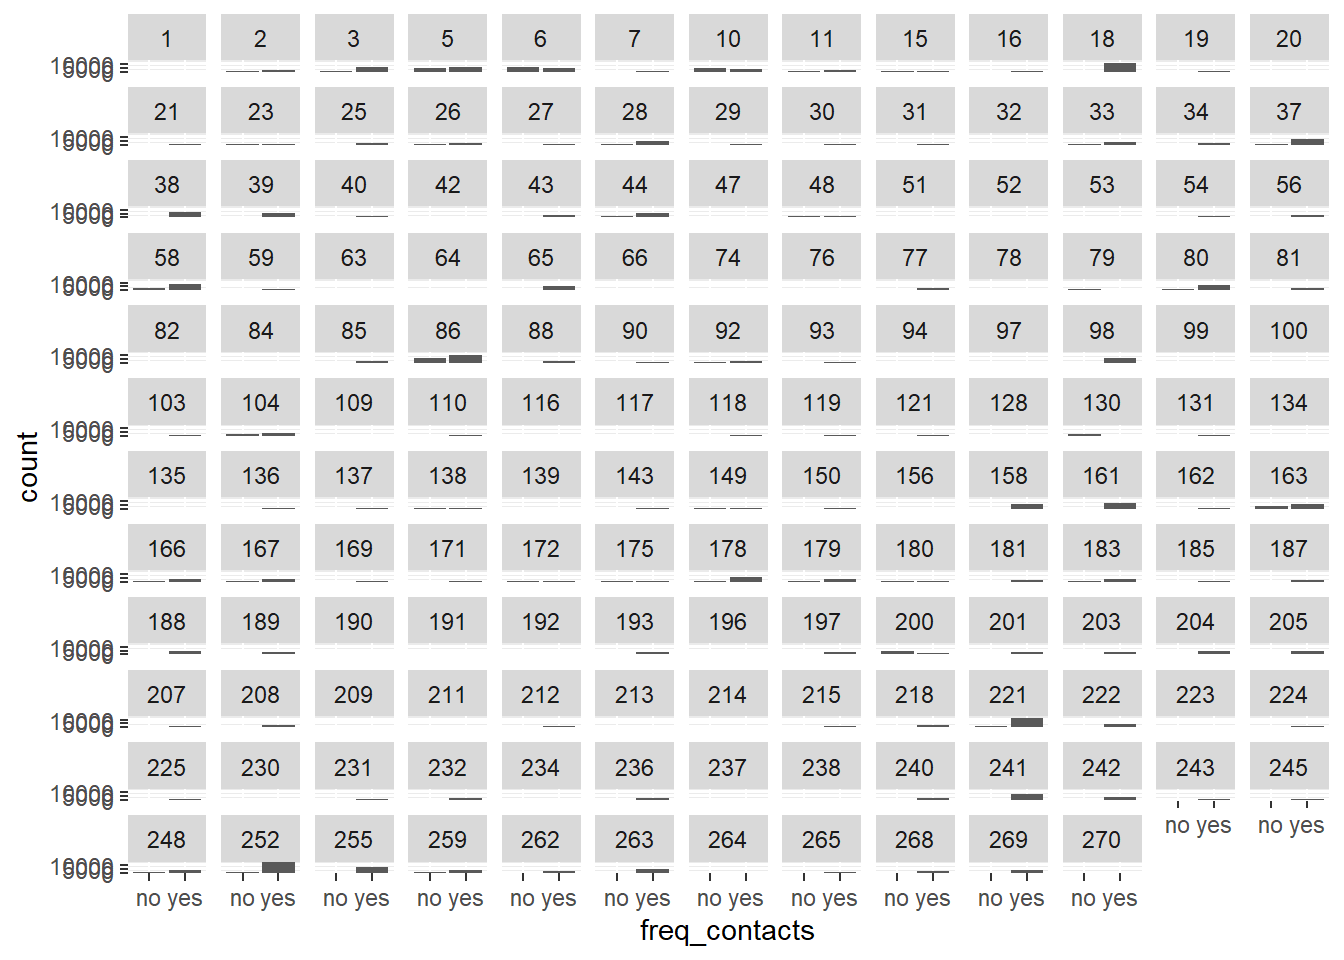

In [ ]:
data |> 
  ggplot(aes(x = freq_contacts)) +
  geom_bar() +
  facet_wrap(~subid)


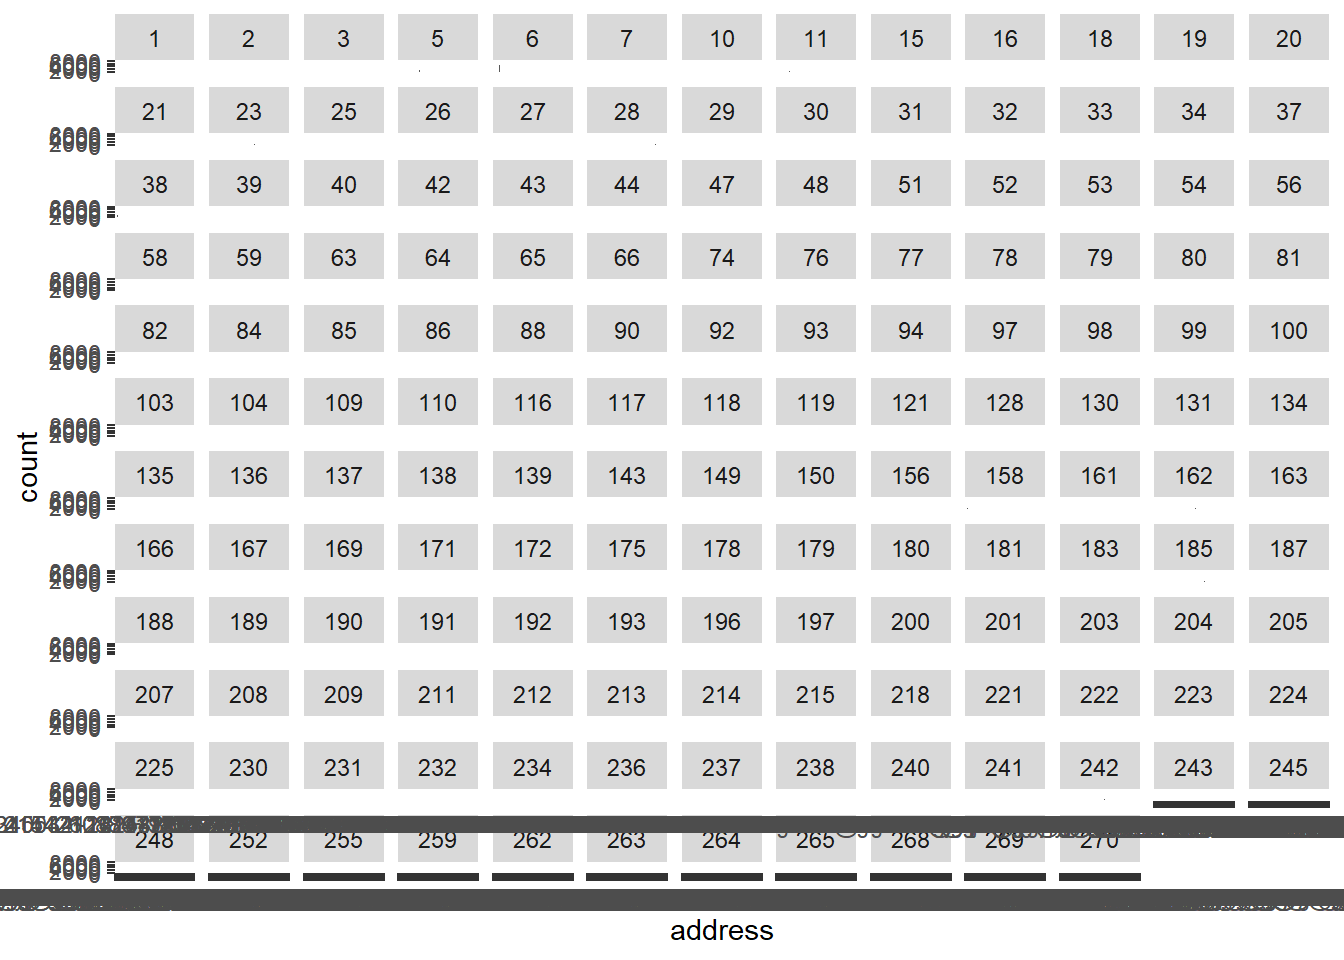

In [ ]:
data |> 
  ggplot(aes(x = address)) +
  geom_bar() +
  facet_wrap(~subid)


## EDA on predictor windows